# MTPL2 Frequency Modelling Walkthrough

End-to-end Poisson frequency model on the full French MTPL2 dataset (678k
policies). Covers data prep, main-effect fitting, interaction fitting,
static plots for export, Plotly exploration, contour/HDR interaction views,
and discretising smooth curves into rating tables.

Sections:

1. **Data loading & preparation**
2. **Model specification** — splines, categoricals, and a spline-spline interaction
3. **Fitting with REML** — automatic smoothness selection on the full dataset
4. **Plotting workflow** — static charts, Plotly explorer, contour/HDR interaction view, plot-data export
5. **Summary table** — statsmodels-style output
6. **Discretisation impact** — binning smooth curves into rating tables
7. **Rating tables** — per-feature step functions for deployment


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from superglm import Categorical, Poisson, Spline, SuperGLM

## 1. Data loading & preparation

The French MTPL2 frequency dataset contains 678k motor third-party
liability policies with claim counts and exposure. We use the local parquet
copy when available and fall back to OpenML otherwise, then apply the
standard actuarial cleaning used throughout the repo.


In [2]:
from sklearn.datasets import fetch_openml

DATA_PATH = Path("../../data/freMTPL2freq.parquet")

if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
else:
    df = fetch_openml(data_id=41214, as_frame=True, parser="auto").frame

# Standard cleaning
claim_count = df["ClaimNb"].astype(float).clip(upper=4)
exposure_series = df["Exposure"].astype(float).clip(lower=0.01)
df["ClaimNb"] = claim_count
df["Exposure"] = exposure_series
df["DrivAge"] = df["DrivAge"].astype(float).clip(18, 90)
df["VehAge"] = df["VehAge"].astype(float).clip(0, 20)
df["BonusMalus"] = df["BonusMalus"].astype(float).clip(50, 150)
df["Density"] = df["Density"].astype(float)
df["VehPower"] = df["VehPower"].astype(float)
df["LogDensity"] = np.log1p(df["Density"])

y = (df["ClaimNb"] / df["Exposure"]).to_numpy(dtype=np.float64)
exposure = df["Exposure"].to_numpy(dtype=np.float64)

features_to_use = ["DrivAge", "VehAge", "BonusMalus", "LogDensity", "Area", "VehPower"]
X = df[features_to_use].copy()

print(f"Rows: {len(df):,}")
print(f"Claim frequency: {df['ClaimNb'].sum() / df['Exposure'].sum():.4f}")
print(f"Zero-claim fraction: {(df['ClaimNb'] == 0).mean():.1%}")
X.describe(include="all").transpose()

Rows: 678,013
Claim frequency: 0.1006
Zero-claim fraction: 95.0%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DrivAge,678013.0,NaN,NaN,NaN,45.496871,14.129872,18.0,34.0,44.0,55.0,90.0
VehAge,678013.0,NaN,NaN,NaN,6.976124,5.398963,0.0,2.0,6.0,11.0,20.0
BonusMalus,678013.0,NaN,NaN,NaN,59.757211,15.607906,50.0,50.0,50.0,64.0,150.0
LogDensity,678013.0,NaN,NaN,NaN,5.992367,1.856253,0.693147,4.532599,5.976351,7.41397,10.203629
Area,678013,6,C,191880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehPower,678013.0,NaN,NaN,NaN,6.454631,2.050906,4.0,5.0,6.0,7.0,15.0


## 2. Model specification

A practical full-sample MTPL2 frequency model mixes smooth main effects,
a categorical region effect, and one continuous × continuous interaction:

| Term | Type | Why |
|------|------|-----|
| DrivAge | `Spline(n_knots=10)` | Smooth driver-age effect |
| VehAge | `Spline(n_knots=8)` | Smooth vehicle-age effect |
| BonusMalus | `Spline(n_knots=8)` | Strong nonlinear tariff effect |
| LogDensity | `Spline(n_knots=7)` | Smooth urbanicity effect |
| Area | `Categorical()` | Geographic rating regions |
| VehPower | `Spline(n_knots=7)` | Smooth power effect |
| DrivAge:VehAge | tensor interaction | Joint age surface for drivers and vehicles |


In [3]:
model = SuperGLM(
    family=Poisson(),
    selection_penalty=0,
    discrete=True,
    features={
        "DrivAge": Spline(n_knots=10, penalty="ssp"),
        "VehAge": Spline(n_knots=8, penalty="ssp"),
        "BonusMalus": Spline(n_knots=8, penalty="ssp"),
        "LogDensity": Spline(n_knots=7, penalty="ssp"),
        "Area": Categorical(base="first"),
        "VehPower": Spline(n_knots=7, penalty="ssp"),
    },
    interactions=[("DrivAge", "VehAge")],
)
print("Model specified.")

Model specified.


## 3. Fitting with REML

`fit_reml()` estimates smoothing parameters automatically via restricted
marginal likelihood (Wood 2011). For count frequency work we model claim
**rate** (`ClaimNb / Exposure`) and pass exposure through `sample_weight=`.

This notebook uses the full MTPL2 dataset and includes one spline-spline
interaction, so the fit may take a little while.


In [4]:
t0 = time.perf_counter()
model.fit_reml(X, y, sample_weight=exposure, max_reml_iter=6)
elapsed = time.perf_counter() - t0

print(f"Fit time: {elapsed:.1f}s")
print(f"REML converged: {model._reml_result.converged}")
print(f"REML iterations: {model._reml_result.n_reml_iter}")
print()
print("Per-feature edf:")
for name in model._feature_order:
    ti = model.term_inference(name, with_se=False)
    edf_str = f"{ti.edf:.1f}" if ti.edf is not None else "—"
    print(f"  {name:15s} edf = {edf_str}")
print()
print(f"Interactions: {list(model._interaction_order)}")

Fit time: 7.0s
REML converged: False
REML iterations: 6

Per-feature edf:


  DrivAge         edf = 9.3
  VehAge          edf = 10.8
  BonusMalus      edf = 9.7
  LogDensity      edf = 1.2
  Area            edf = 5.0
  VehPower        edf = 8.5

Interactions: ['DrivAge:VehAge']


## 4. Plotting workflow

### 4a. All main effects in a static grid

The default `model.plot()` remains the export-friendly path: a matplotlib
figure with main effects, density overlays, and confidence intervals.


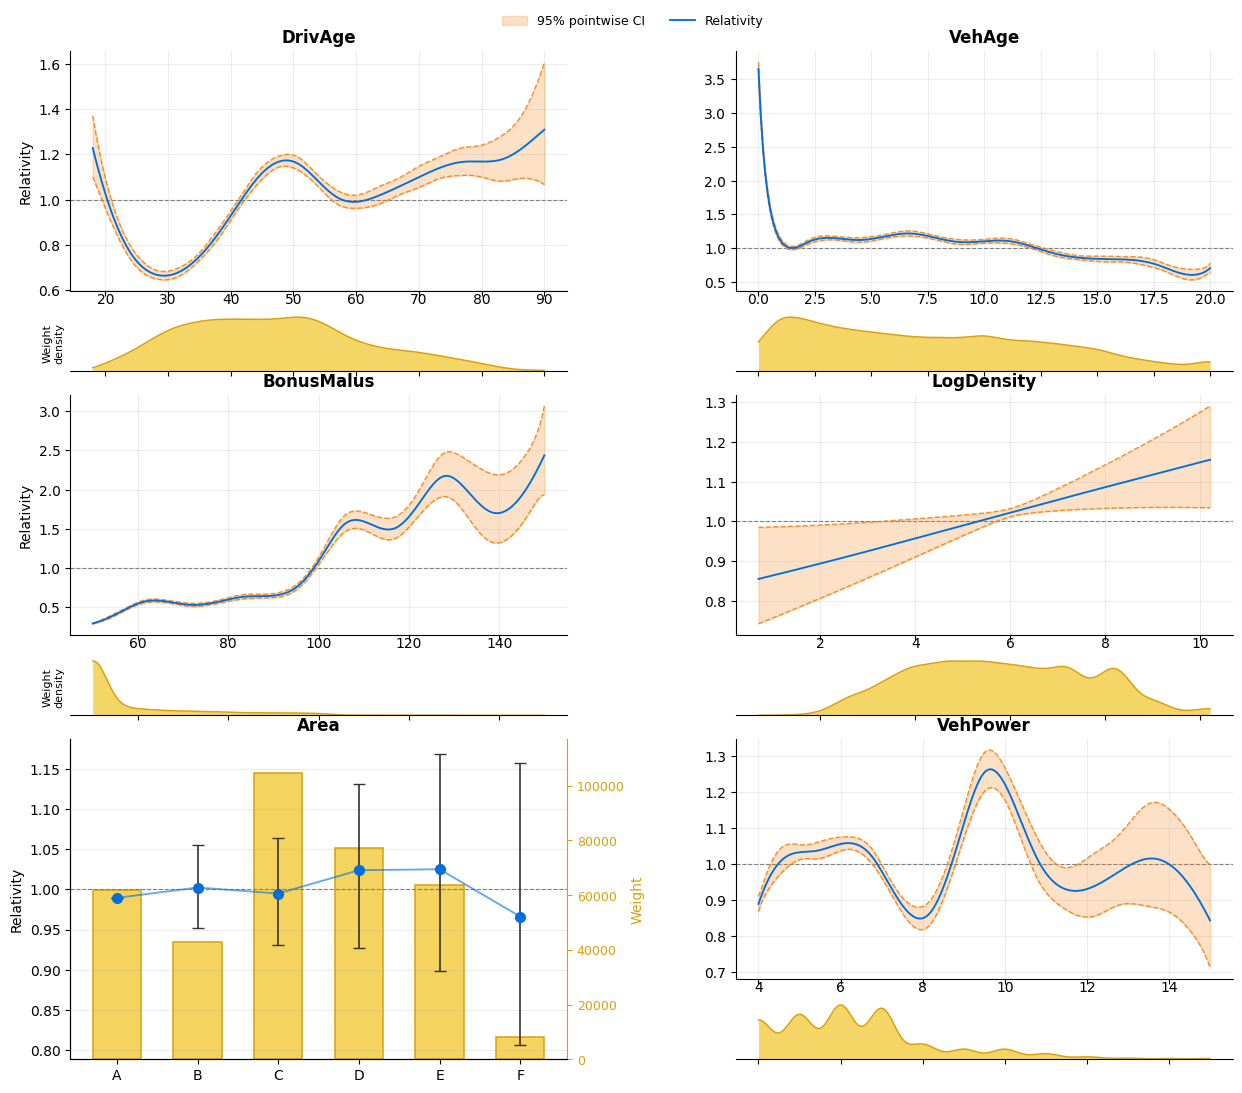

In [5]:
fig = model.plot(
    X=X,
    sample_weight=exposure,
    figsize=(15, 12),
)
fig.subplots_adjust(wspace=0.34, hspace=0.24)
plt.show()

### 4b. Plotly multi-term explorer

For interactive inspection, `engine="plotly"` is the multi-term main-effect
explorer path. This gives a term dropdown plus a response/link scale toggle.


In [6]:
fig = model.plot(
    engine="plotly",
    X=X,
    sample_weight=exposure,
    ci="pointwise",
    show_knots=True,
)
fig

### 4c. Continuous interaction contour + exposure HDR view

For spline-spline interactions, Plotly can render a side-by-side figure with
an interaction contour on the left and exposure highest-density-region (HDR)
mass contours on the right.


In [7]:
fig = model.plot(
    "DrivAge:VehAge",
    engine="plotly",
    interaction_view="contour_pair",
    X=X,
    sample_weight=exposure,
    n_points=220,
)
fig

### 4d. Exporting raw plot data

`model.plot_data()` returns the underlying x/y/grid data so you can rebuild
charts outside SuperGLM in matplotlib, plotly, Excel, or another reporting
stack.


In [8]:
payload = model.plot_data("DrivAge:VehAge", X=X, sample_weight=exposure, n_points=220)
print(payload["effect"].head())
print()
print(payload["density"].head())

     DrivAge  VehAge  relativity  log_relativity
0  18.000000     0.0    0.704085       -0.350856
1  18.328767     0.0    0.712220       -0.339369
2  18.657534     0.0    0.720476       -0.327843
3  18.986301     0.0    0.728852       -0.316285
4  19.315068     0.0    0.737343       -0.304702

     DrivAge  VehAge   density  hdr_mass
0  18.000000     0.0  0.037695  0.993639
1  18.328767     0.0  0.042701  0.992064
2  18.657534     0.0  0.048154  0.990180
3  18.986301     0.0  0.054063  0.987856
4  19.315068     0.0  0.060433  0.985071


## 5. Summary table

statsmodels-style summary with coefficient estimates, smooth term
edf, and Wood (2013) p-values for smooth terms.

In [9]:
model.summary()

╔═════════════════════════════════ SuperGLM Results ═════════════════════════════════╗
║ Family:                          Poisson  No. Observations:                 678013 ║
║ Link:                                Log  Df (effective):     64.18 (39.51 smooth) ║
║ Method:                   REML, discrete  Penalty:                            None ║
║ Scale (phi):                       1.000  Pearson chi2:                  1410069.5 ║
║ Log-Likelihood:                -130663.1  AIC:                            261454.6 ║
║ AICc:                           261454.6  BIC:                            262188.0 ║
║ EBIC:                           262188.0  Converged:                 True (2 iter) ║
║ Deviance:                       211532.1                                           ║
╠════════════════════════════════════════════════════════════════════════════════════╣
║                     coef   std err     z     P>|z|   [0.025   0.975]               ║
╟────────────────────────────────────────────────────────────────────────────────────╢
║ Intercept        -2.3609    0.0382 -61.855   0.000   -2.436   -2.286 ***           ║
║                                                                                    ║
╠════════════════════════════════════╡ DrivAge ╞═════════════════════════════════════╣
║                                                                                    ║
║ DrivAge         [spline, 13 params, chi2(10.4)=1019.6, p=<0.001]               *** ║
║                   rank=13, edf=9.3, lam=12, curve SE: 0.01-0.10                    ║
║                                                                                    ║
╠═════════════════════════════════════╡ VehAge ╞═════════════════════════════════════╣
║                                                                                    ║
║ VehAge          [spline, 11 params, chi2(10.9)=6985.6, p=<0.001]               *** ║
║                   rank=11, edf=10.8, lam=0.065, curve SE: 0.01-0.07                ║
║                                                                                    ║
╠═══════════════════════════════════╡ BonusMalus ╞═══════════════════════════════════╣
║                                                                                    ║
║ BonusMalus      [spline, 11 params, chi2(10.1)=5402.1, p=<0.001]               *** ║
║                   rank=11, edf=9.7, lam=0.49, curve SE: 0.01-0.13                  ║
║                                                                                    ║
╠═══════════════════════════════════╡ LogDensity ╞═══════════════════════════════════╣
║                                                                                    ║
║ LogDensity      [spline, 10 params, chi2(1.1)=5.6, p=0.017]                    *   ║
║                   rank=10, edf=1.2, lam=1.3e+04, curve SE: 0.01-0.07               ║
║                                                                                    ║
╠══════════════════════════════════════╡ Area ╞══════════════════════════════════════╣
║                                                                                    ║
║ Area[B]           0.0130    0.0260   0.498   0.619   -0.038    0.064               ║
║ Area[C]           0.0055    0.0342   0.160   0.873   -0.062    0.072               ║
║ Area[D]           0.0342    0.0509   0.673   0.501   -0.065    0.134               ║
║ Area[E]           0.0354    0.0670   0.528   0.597   -0.096    0.167               ║
║ Area[F]          -0.0237    0.0920  -0.258   0.797   -0.204    0.157               ║
║                                                                                    ║
╠════════════════════════════════════╡ VehPower ╞════════════════════════════════════╣
║                                                                                    ║
║ VehPower        [spline, 10 params, chi2(9.0)=271.5, p=<0.001]                 *** ║
║                   rank=10, edf=8.5, lam=1.2, curve SE: 0.01-0.09                   

## 6. Discretisation impact

In production, smooth spline curves are typically discretised into
step-function rating tables (for example 10–20 age bands).
`discretization_impact()` covers every smooth term a rating table
approximates — the spline and polynomial main effects, and the
`DrivAge`×`VehAge` interaction, which is sampled onto an
`n_bins`-per-axis grid rather than binned into intervals.  Its metrics are
**joint** over everything discretised in the call.

This section wants the main effects' binning error on its own, so that the
step-function plots below compare like with like, so it fits a companion
main-effects-only model with the same feature set.  Run the diagnostic on
`model` instead to see the interaction's share included — its grid appears
in `result.interaction_tables`, keyed on `"DrivAge:VehAge"`.


In [10]:
t0 = time.perf_counter()
main_effect_model = SuperGLM(
    family=Poisson(),
    selection_penalty=0,
    discrete=True,
    features={
        "DrivAge": Spline(n_knots=10, penalty="ssp"),
        "VehAge": Spline(n_knots=8, penalty="ssp"),
        "BonusMalus": Spline(n_knots=8, penalty="ssp"),
        "LogDensity": Spline(n_knots=7, penalty="ssp"),
        "Area": Categorical(base="first"),
        "VehPower": Spline(n_knots=7, penalty="ssp"),
    },
)
main_effect_model.fit_reml(X, y, sample_weight=exposure, max_reml_iter=6)
print(f"Companion main-effect fit time: {time.perf_counter() - t0:.1f}s")
print()
# Compare bin counts: how many bins before the error is negligible?
for n_bins in [5, 10, 20, 50, 100]:
    r = main_effect_model.discretization_impact(X, y, sample_weight=exposure, n_bins=n_bins)
    m = r.metrics
    print(
        f"  {n_bins:3d} bins: "
        f"deviance change {m['deviance_change_pct']:+.4f}%, "
        f"mean pred change {m['mean_abs_prediction_change_pct']:.4f}%, "
        f"corr {m['prediction_correlation']:.6f}"
    )

Companion main-effect fit time: 1.4s



    5 bins: deviance change +3.3565%, mean pred change 24.5309%, corr 0.596113


   10 bins: deviance change +0.8147%, mean pred change 10.2954%, corr 0.901808


   20 bins: deviance change +0.4735%, mean pred change 6.1482%, corr 0.937927


   50 bins: deviance change +0.1276%, mean pred change 1.9306%, corr 0.981421


  100 bins: deviance change +0.0781%, mean pred change 1.3647%, corr 0.982596


## 7. Rating tables

Using the companion main-effects-only fit, we can compare the smooth curves
with the 20-bin rating tables that would be exported for deployment.


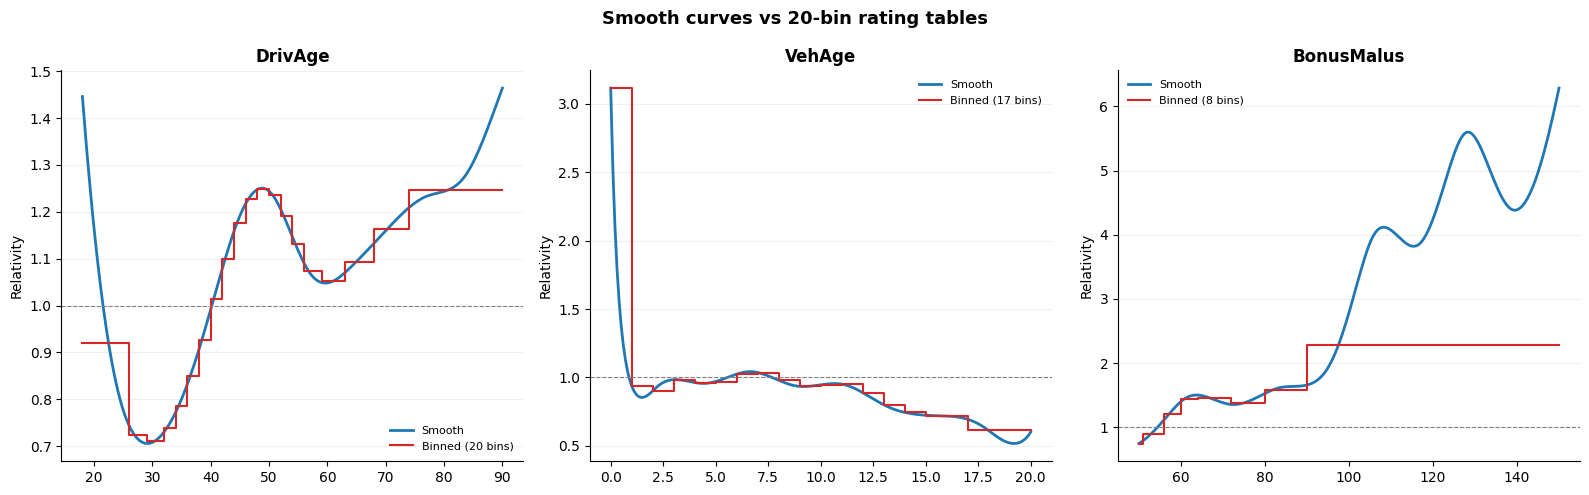

In [11]:
result = main_effect_model.discretization_impact(X, y, sample_weight=exposure, n_bins=20)

spline_names = ["DrivAge", "VehAge", "BonusMalus"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, spline_names):
    # Smooth curve on native scale (no mean centering) to match rating table
    ti = main_effect_model.term_inference(name, centering="native")
    ax.plot(ti.x, ti.relativity, color="#1f77b4", linewidth=2, label="Smooth")

    # Step function from rating table
    table = result.tables[name]
    step_x, step_y = [], []
    for _, row in table.iterrows():
        step_x.extend([row["bin_from"], row["bin_to"]])
        step_y.extend([row["relativity"], row["relativity"]])
    ax.plot(step_x, step_y, color="#d62728", linewidth=1.5, label=f"Binned ({len(table)} bins)")

    ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Relativity")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.2, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Smooth curves vs 20-bin rating tables", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

## 8. Key takeaways

| | Detail |
|---|---|
| **REML** | Automatic smoothness selection on the full MTPL2 frequency model |
| **Static plots** | `engine="matplotlib"` remains the clean export/report path |
| **Interactive plots** | `engine="plotly"` gives a multi-term explorer plus contour/HDR interaction views |
| **Plot data export** | `plot_data()` returns the raw curve, grid, density, and HDR data for custom reporting |
| **Discretisation** | 10–20 bins per feature is enough for tiny approximation error |

The smooth model is the statistical model. The rating table is what goes into
production pricing. SuperGLM now supports the full path from full-data MTPL2
fit, to interactive inspection, to exportable figures, to raw plot payloads,
to deployment-oriented rating tables.
